In [ ]:
#Instalo el modulo Pyspark en google colab
!pip install pyspark

#Importo la sesion Spark
from pyspark.sql import SparkSession

#Importo el mdulo para acceder a google Drive
from google.colab import drive

#Monto Google drive
drive.mount('/content/drive')

#Creo la sesion Spark

spark= SparkSession.builder.appName("Projecto_final").getOrCreate()

Mounted at /content/drive


In [ ]:
# Importo el DataFrames Spark desde del CSV en Drive y separo los datos con ","
df_customer = spark.read.csv(
    "/content/drive/MyDrive/Master_Big_data/Projecto_final/customer_churn_10k.csv",
    header=True,
    inferSchema=True,
    sep=","
)

df_customer.show(5)
df_customer.printSchema()

+----------+----+------+------+---------------+-------------+-------------+-----------------+---------------+-----------+----------------+-----------+
|CustomerID| Age|Gender|Tenure|Usage Frequency|Support Calls|Payment Delay|Subscription Type|Contract Length|Total Spend|Last Interaction|Churn_YesNo|
+----------+----+------+------+---------------+-------------+-------------+-----------------+---------------+-----------+----------------+-----------+
|  314921.0|36.0|  Male|  10.0|           14.0|          1.0|         20.0|         Standard|         Annual|     736.02|            27.0|         No|
|  401716.0|40.0|  Male|  20.0|           23.0|          4.0|          6.0|         Standard|      Quarterly|      897.3|            29.0|         No|
|   99832.0|36.0|Female|  52.0|           23.0|          1.0|          0.0|         Standard|      Quarterly|      697.0|            29.0|        Yes|
|  168747.0|65.0|  Male|  55.0|            3.0|         10.0|         14.0|            Basic| 

In [ ]:
#Agrupo el numero de clientes por tipo de tarifa

from pyspark.sql.functions import col, when, avg

#Calculo el % de clientes que han abandonado la compañia o el churn (%) por tipo de tarifa. Para ello importo las funciones, col, when avg. Este código Convierte:
#Yes → 1
#No → 0
#y calcula la media.

# Importo las funciones necesarias
from pyspark.sql.functions import col, when, avg

churn_subscription = df_customer.groupBy("Subscription Type").agg(
    avg(
        when(col("Churn_YesNo") == "Yes", 1).otherwise(0)
    ).alias("Churn_Rate")
)

# Muestro el resultado
churn_subscription.show()


+-----------------+------------------+
|Subscription Type|        Churn_Rate|
+-----------------+------------------+
|          Premium|0.5528479154433353|
|            Basic|0.5827404887101763|
|         Standard|0.5667955965486462|
+-----------------+------------------+



In [ ]:
#Calculo el numero de l por tarifa

from pyspark.sql.functions import count

clientes_tarifa = df_customer.groupBy("Subscription Type").agg(
    count("*").alias("Num_Clientes")
)

clientes_tarifa.show()

+-----------------+------------+
|Subscription Type|Num_Clientes|
+-----------------+------------+
|          Premium|        3406|
|            Basic|        3233|
|         Standard|        3361|
+-----------------+------------+



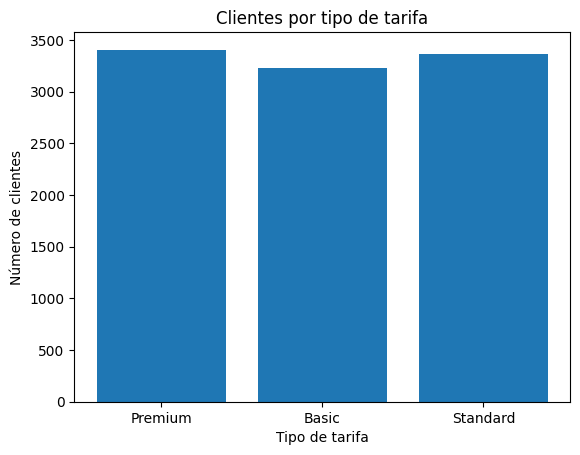

In [ ]:
#Procedo a generear el primer grafico de numero de clientes por tarifa importando la libreria matplotlib
#Antes de hacer el gráfico tengo que convertir el DataFrame de PySpark a Pandas.

import matplotlib.pyplot as plt

subscription_pd = clientes_tarifa.toPandas()

plt.bar(
    subscription_pd["Subscription Type"],
    subscription_pd["Num_Clientes"]
)

plt.xlabel("Tipo de tarifa")
plt.ylabel("Número de clientes")
plt.title("Clientes por tipo de tarifa")

plt.show()

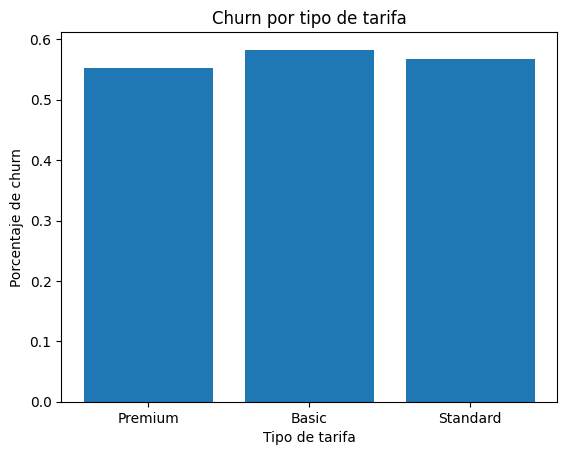

In [ ]:
#A continuación genero el gráfico del churn por tipo de tarifa:

import matplotlib.pyplot as plt

subscription_pd = churn_subscription.toPandas()

plt.bar(
    subscription_pd["Subscription Type"],
    subscription_pd["Churn_Rate"]
)

plt.xlabel("Tipo de tarifa")
plt.ylabel("Porcentaje de churn")
plt.title("Churn por tipo de tarifa")

plt.show()

In [ ]:
# Agrupo el número de clientes por duración del contrato

from pyspark.sql.functions import count

clientes_contrato = df_customer.groupBy("Contract Length").agg(
    count("*").alias("Num_Clientes")
)

clientes_contrato.show()

+---------------+------------+
|Contract Length|Num_Clientes|
+---------------+------------+
|         Annual|        4046|
|      Quarterly|        3970|
|        Monthly|        1984|
+---------------+------------+



In [ ]:
#Calculo el porcentaje de churn por duración del contrato

from pyspark.sql.functions import col, when, avg

churn_contract = df_customer.groupBy("Contract Length").agg(
    avg(
        when(col("Churn_YesNo") == "Yes", 1).otherwise(0)
    ).alias("Churn_Rate")
)

churn_contract.show()


+---------------+-------------------+
|Contract Length|         Churn_Rate|
+---------------+-------------------+
|         Annual| 0.4505684626791893|
|      Quarterly|0.46977329974811083|
|        Monthly|                1.0|
+---------------+-------------------+



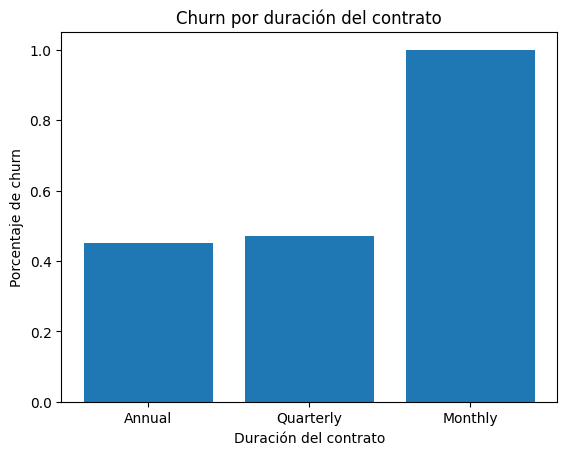

In [ ]:
#Gráfico del churn por duración del contrato

import matplotlib.pyplot as plt

contract_pd = churn_contract.toPandas()

plt.bar(
    contract_pd["Contract Length"],
    contract_pd["Churn_Rate"]
)

plt.xlabel("Duración del contrato")
plt.ylabel("Porcentaje de churn")
plt.title("Churn por duración del contrato")

plt.show()

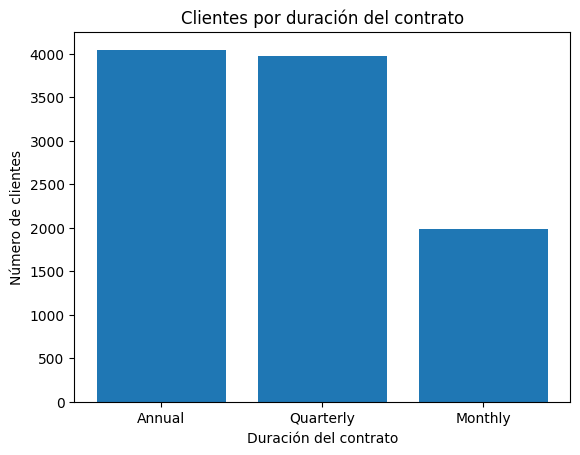

In [ ]:
#Gráfico del número de clientes por duración del contrato
import matplotlib.pyplot as plt

contract_pd = clientes_contrato.toPandas()

plt.bar(
    contract_pd["Contract Length"],
    contract_pd["Num_Clientes"]
)

plt.xlabel("Duración del contrato")
plt.ylabel("Número de clientes")
plt.title("Clientes por duración del contrato")

plt.show()

In [ ]:
#En este apartado se realiza un análisis descriptivo de las variables numéricas del conjunto de datos mediante PySpark.
#Para ello, se calcula la media y la desviación estándar de cada variable cuantitativa, excluyendo el campo CustomerID

from pyspark.sql.functions import mean, stddev

df_customer.select(

    mean("Age").alias("Age_mean"),
    stddev("Age").alias("Age_std"),

    mean("Tenure").alias("Tenure_mean"),
    stddev("Tenure").alias("Tenure_std"),

    mean("Usage Frequency").alias("Usage_mean"),
    stddev("Usage Frequency").alias("Usage_std"),

    mean("Support Calls").alias("Support_mean"),
    stddev("Support Calls").alias("Support_std"),

    mean("Payment Delay").alias("PaymentDelay_mean"),
    stddev("Payment Delay").alias("PaymentDelay_std"),

    mean("Total Spend").alias("TotalSpend_mean"),
    stddev("Total Spend").alias("TotalSpend_std"),

    mean("Last Interaction").alias("LastInteraction_mean"),
    stddev("Last Interaction").alias("LastInteraction_std")

).show()

+--------+------------------+-----------+-----------------+----------+-----------------+------------+------------------+-----------------+-----------------+-----------------+------------------+--------------------+-------------------+
|Age_mean|           Age_std|Tenure_mean|       Tenure_std|Usage_mean|        Usage_std|Support_mean|       Support_std|PaymentDelay_mean| PaymentDelay_std|  TotalSpend_mean|    TotalSpend_std|LastInteraction_mean|LastInteraction_std|
+--------+------------------+-----------+-----------------+----------+-----------------+------------+------------------+-----------------+-----------------+-----------------+------------------+--------------------+-------------------+
| 39.2613|12.492486883437296|    30.9536|17.13792338300609|   15.7726|8.631357904404563|      3.5932|3.0796529327537288|          13.0305|8.261863929499139|633.3173110000018|240.47176902802795|             14.4916|  8.621076599600162|
+--------+------------------+-----------+-----------------+-

In [ ]:
#En este apartado se realiza un análisis de correlación mediante una matriz de correlación de datos que represente
#de qué manera están relacionadas las diferentes variables numéricas.

#Como primer paso importo las librerias necesarias

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

#Selecciono las variables numericas

columnas = [
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Total Spend",
    "Last Interaction"
]

#Creo un objeto VectorAssembler, encargado de combinar todas las variables numéricas del conjunto de datos en una única columna denominada features
assembler = VectorAssembler(
    inputCols=columnas,
    outputCol="features"
)

df_vector = assembler.transform(df_customer).select("features")

#Calculo la matriz de correlación

correlation = Correlation.corr(
    df_vector,
    "features",
    "pearson"
).collect()[0][0]

print(correlation)

#Muestro la matriz de correlación como una tabla.

import pandas as pd

corr_df = pd.DataFrame(
    correlation.toArray(),
    columns=columnas,
    index=columnas
)

corr_df

DenseMatrix([[ 1.00000000e+00, -6.93105037e-04, -4.41102312e-03,
               1.75940465e-01,  5.38108684e-02, -7.65825742e-02,
               3.31619836e-02],
             [-6.93105037e-04,  1.00000000e+00, -3.17401851e-02,
              -1.86982872e-02,  7.87497227e-03,  1.38211881e-02,
               2.08356376e-03],
             [-4.41102312e-03, -3.17401851e-02,  1.00000000e+00,
              -3.24770925e-02, -3.36540053e-02,  2.98365903e-02,
              -1.03570848e-02],
             [ 1.75940465e-01, -1.86982872e-02, -3.24770925e-02,
               1.00000000e+00,  1.64218631e-01, -2.25403041e-01,
               7.36943183e-02],
             [ 5.38108684e-02,  7.87497227e-03, -3.36540053e-02,
               1.64218631e-01,  1.00000000e+00, -1.22546506e-01,
               4.40346603e-02],
             [-7.65825742e-02,  1.38211881e-02,  2.98365903e-02,
              -2.25403041e-01, -1.22546506e-01,  1.00000000e+00,
              -6.27191846e-02],
             [ 3.31619836e-0

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction
Age,1.000000,-0.000693,-0.004411,0.175940,0.053811,-0.076583,0.033162
Tenure,-0.000693,1.000000,-0.031740,-0.018698,0.007875,0.013821,0.002084
Usage Frequency,-0.004411,-0.031740,1.000000,-0.032477,-0.033654,0.029837,-0.010357
Support Calls,0.175940,-0.018698,-0.032477,1.000000,0.164219,-0.225403,0.073694
Payment Delay,0.053811,0.007875,-0.033654,0.164219,1.000000,-0.122547,0.044035
Total Spend,-0.076583,0.013821,0.029837,-0.225403,-0.122547,1.000000,-0.062719
Last Interaction,0.033162,0.002084,-0.010357,0.073694,0.044035,-0.062719,1.000000


In [ ]:
#Modelo predictivo mediante Aprendizaje Supervisado

#Importo las librerías necesarias

from pyspark.ml.feature import StringIndexer
from pyspark.ml.feature import OneHotEncoder
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [ ]:
#Utilizo "OneHotEncoder", que transforma cada categoría en una representación binaria (vector de 0 y 1),
#eliminando cualquier interpretación numérica entre las distintas categorías.

encoder = OneHotEncoder(

    inputCols=[
        "Gender_Index",
        "Subscription_Index",
        "Contract_Index"
    ],

    outputCols=[
        "Gender_Vector",
        "Subscription_Vector",
        "Contract_Vector"
    ]
)

In [ ]:
#Creo el vector para reunir todas las variables
assembler = VectorAssembler(

    inputCols=[

        "Age",
        "Tenure",
        "Usage Frequency",
        "Support Calls",
        "Payment Delay",
        "Total Spend",
        "Last Interaction",

        "Gender_Vector",
        "Subscription_Vector",
        "Contract_Vector"

    ],

    outputCol="features"
)

In [ ]:
# Creo el árbol de decisión.
dt = DecisionTreeClassifier(

    labelCol="label",
    featuresCol="features"
)

In [ ]:
# Creo el Pipeline

pipeline = Pipeline(

    stages=[

        gender_indexer,
        subscription_indexer,
        contract_indexer,
        label_indexer,

        encoder,

        assembler,

        dt

    ]
)

In [ ]:
#Divido el dataset para la prueba y el entrenamiento

train, test = df_customer.randomSplit(

    [0.8,0.2],

    seed=123
)

In [ ]:


from pyspark.ml.tuning import ParamGridBuilder


#Utilizo el comando GridSearch, esto permitirá probar diferentes configuraciones del modelo para encontrar la mejor

# Creo las diferentes profundidades que quiero probar

paramGrid = ParamGridBuilder() \
    .addGrid(tree.maxDepth, [3, 5, 7, 10]) \
    .build()


#usaré el comando Crossvalidation para evaluar el rendimiento de los 4 arboles y evitar el sobreajuste

from pyspark.ml.tuning import CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

#Creo el CrossValidation

crossval = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=5,
    seed=123
)

#Entreno el modelo

modelo_cv = crossval.fit(train)

In [ ]:
#Generación de predicciones. Una vez entrenado el modelo, se aplica sobre el conjunto de prueba mediante el método “train” y “test”

best_tree = modelo_cv.bestModel.stages[-1]
print("Mejor maxDepth:", best_tree.getMaxDepth())




Mejor maxDepth: 5


In [ ]:
#Realizo las predicciones


pred_train = modelo_cv.transform(train)
pred_test = modelo_cv.transform(test)

In [ ]:
#Calculo el accuracy

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)


accuracy_test = accuracy_evaluator.evaluate(pred_test)

print("Accuracy Test:", accuracy_test)

Accuracy Test: 0.9621062992125984


In [ ]:
#A continuacion evaluo la precisión del modelo con AUC:


auc_test = evaluator.evaluate(pred_test)

print("AUC Test:", auc_test)

AUC Test: 0.9666226867464541


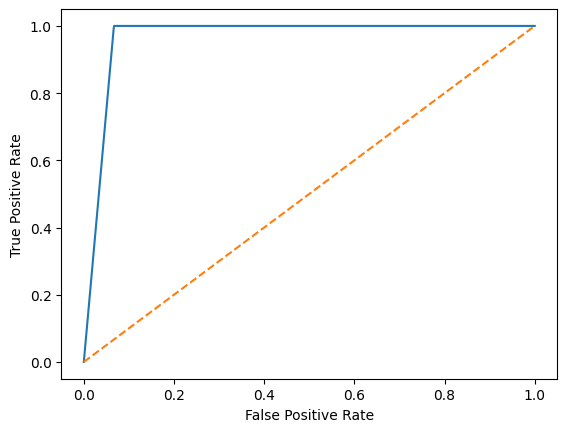

In [ ]:
#Calculo la curva ROC
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

roc_test = pred_test.select(
    "label",
    "probability"
).toPandas()

y_test = roc_test["label"]
y_score_test = roc_test["probability"].apply(lambda x: float(x[1]))

fpr_test, tpr_test, _ = roc_curve(
    y_test,
    y_score_test
)

#Dibujo la curva ROC

fpr_test
tpr_test
plt.plot(
    fpr_test,
    tpr_test
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random"
)
